In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
import pandas as pd
df=pd.read_csv("ecommerce_sales_34500.csv")
df.head(10)


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male
5,O100005,C15191,P214062,Beauty,53.91,0.10,2,Credit Card,2024-04-14,5,South,No,97.04,6.32,37.35,35,Female
6,O100006,C13772,P201363,Electronics,266.50,0.00,1,PayPal,2025-05-20,5,East,No,266.50,9.10,22.88,49,Male
7,O100007,C13092,P216691,Beauty,9.98,0.00,1,Credit Card,2023-09-14,4,West,No,9.98,4.51,-0.02,66,Other
8,O100008,C15734,P202751,Fashion,6.61,0.05,1,Debit Card,2023-10-23,6,West,No,6.28,3.43,-1.23,37,Female
9,O100009,C16265,P207782,Grocery,10.91,0.00,1,Credit Card,2023-10-31,6,South,No,10.91,2.76,-1.89,56,Male


## Dataset Overview

This dataset contains e-commerce sales data, including information such as order details, customers, products, and transactions.

It includes features like product category, price, discount, quantity, and payment method.

The goal of this analysis is to explore the dataset and understand sales trends, customer behavior, and overall product performance.

In [7]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  str    
 1   customer_id         34500 non-null  str    
 2   product_id          34500 non-null  str    
 3   category            34500 non-null  str    
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  str    
 8   order_date          34500 non-null  str    
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  str    
 11  returned            34500 non-null  str    
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  customer_gender

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [8]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

The dataset was examined for missing values and duplicate records to ensure data quality.

No missing values were found in any of the columns, and there were no duplicate entries present in the dataset.

Since the data was already clean and consistent, no additional preprocessing was required before proceeding with the analysis.

In [11]:
total_revenue= df['total_amount'].sum()
print("Total revenue:",total_revenue)

Total revenue: 5865293.05


In [12]:
total_orders=df['order_id'].nunique()
print("Total Orders:", total_orders)

Total Orders: 34500


In [14]:
avg_order_value=total_revenue/total_orders
print("Average Order Value:", avg_order_value)

Average Order Value: 170.00849420289853


## Sales Overview

This section provides a general overview of the dataset by analyzing key metrics such as total revenue, total number of orders, and average order value.

These metrics help in understanding the overall performance of the e-commerce platform.

In [17]:
top_categories=df['category'].value_counts().head(10)
top_categories

category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

C:\Users\sneha chauhan\AppData\Local\Temp\ipykernel_9376\3549312913.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index,y=top_categories.values,palette="viridis")


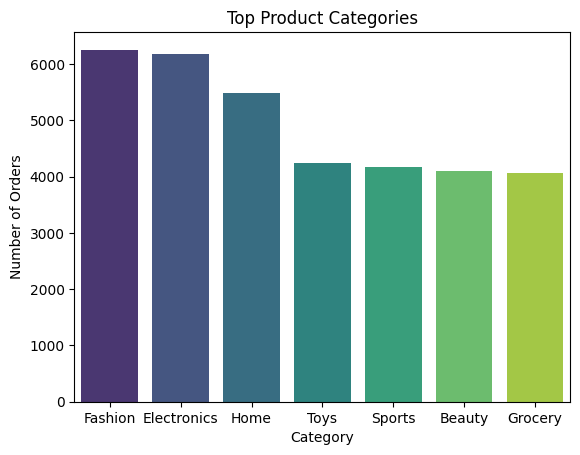

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=top_categories.index,y=top_categories.values,palette="viridis")
plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.show()


## Category Analysis

 Categories like Fashion and Electronics have the highest number of orders, indicating strong customer demand.
 Home category also shows significant sales compared to others.
 Categories such as Grocery and Beauty have relatively lower order counts.
 This suggests that customer interest is more focused on certain categories, which contribute more to overall sales.

In [24]:
top_products=df['product_id'].value_counts().head(10)
top_products

product_id
P200645    7
P237997    6
P235301    6
P224107    6
P218083    6
P243798    5
P212134    5
P222447    5
P206486    5
P221997    5
Name: count, dtype: int64

C:\Users\sneha chauhan\AppData\Local\Temp\ipykernel_9376\4135202698.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, palette="viridis")


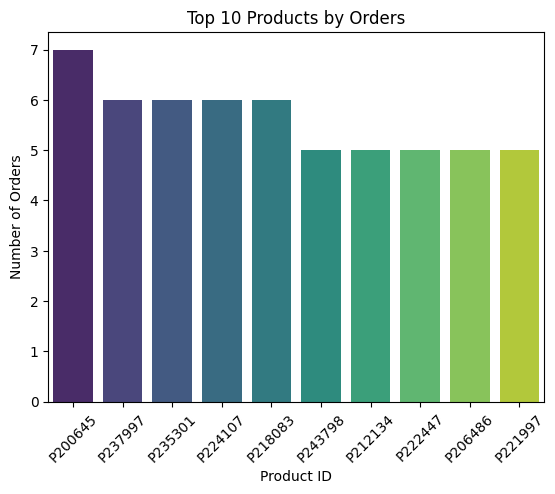

In [25]:
sns.barplot(x=top_products.index, y=top_products.values, palette="viridis")
plt.title("Top 10 Products by Orders")
plt.xlabel("Product ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


## Product Analysis

 Certain products have significantly higher order counts, indicating strong demand.
 These top-performing products contribute a major share of total sales.
 Identifying such products can help businesses focus on inventory and marketing strategies.

In [28]:
product_revenue=df.groupby('product_id')['total_amount'].sum().sort_values(ascending=False).head(10)
product_revenue

product_id
P217031    13035.01
P242326    11747.30
P224743    11298.30
P216077     8035.78
P225406     6786.53
P204291     6279.08
P208695     6227.16
P219612     6032.83
P247375     5662.93
P218610     5438.13
Name: total_amount, dtype: float64

C:\Users\sneha chauhan\AppData\Local\Temp\ipykernel_9376\1108599572.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_revenue.index, y=product_revenue.values, palette="viridis")


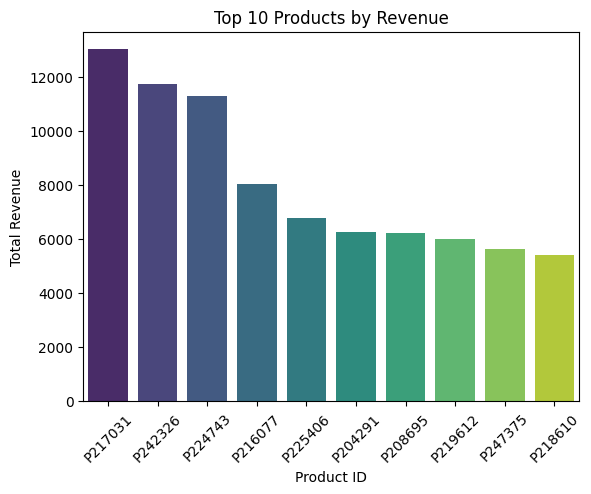

In [29]:
sns.barplot(x=product_revenue.index, y=product_revenue.values, palette="viridis")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


## Revenue-Based Product Analysis


 Some products generate higher revenue even if they are not the most frequently ordered.
 High-revenue products play a key role in overall business profitability.
 This highlights the importance of focusing not just on quantity sold, but also on value generated by each product.

In [32]:
payment_counts=df['payment_method'].value_counts()
payment_counts

payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64

C:\Users\sneha chauhan\AppData\Local\Temp\ipykernel_9376\2775486147.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis")


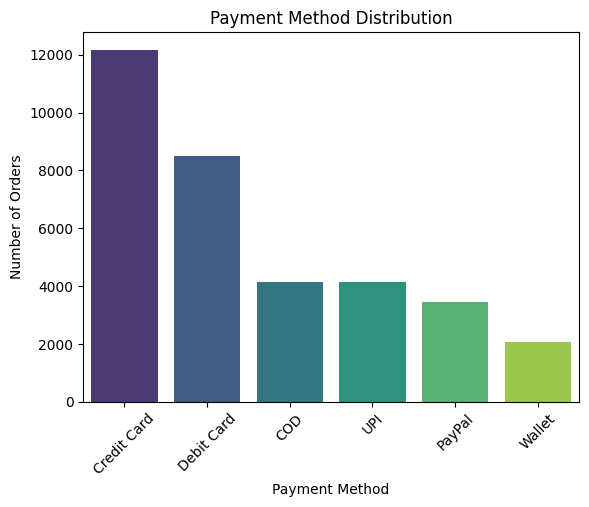

In [36]:
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## Payment Method Analysis

 Certain payment methods are used more frequently than others, indicating customer preference.
 Digital payment methods such as credit cards or online payments may dominate due to convenience.
 Less frequently used methods may indicate limited adoption or lower customer trust.

In [38]:
gender_count=df['customer_gender'].value_counts()
gender_count

customer_gender
Female    16818
Male      16310
Other      1372
Name: count, dtype: int64

C:\Users\sneha chauhan\AppData\Local\Temp\ipykernel_9376\1436939456.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_count.index, y=gender_count.values, palette="viridis")


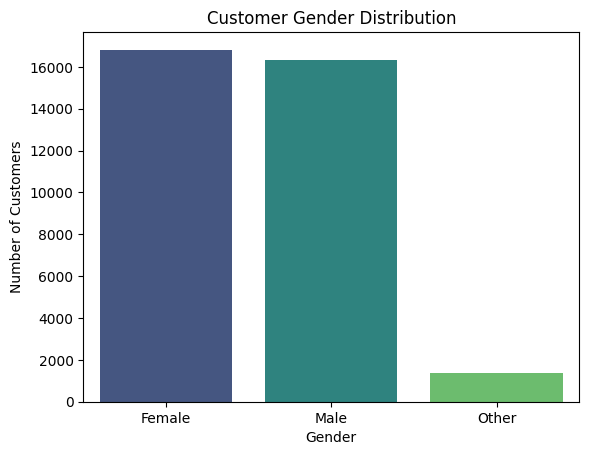

In [39]:
sns.barplot(x=gender_count.index, y=gender_count.values, palette="viridis")
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

### Gender Distribution

This visualization shows the distribution of customers based on gender.

Female customers represent the largest portion of the dataset, followed by male customers, while the 'Other' category has significantly fewer entries.

This indicates that the majority of customers in the dataset belong to the female segment.

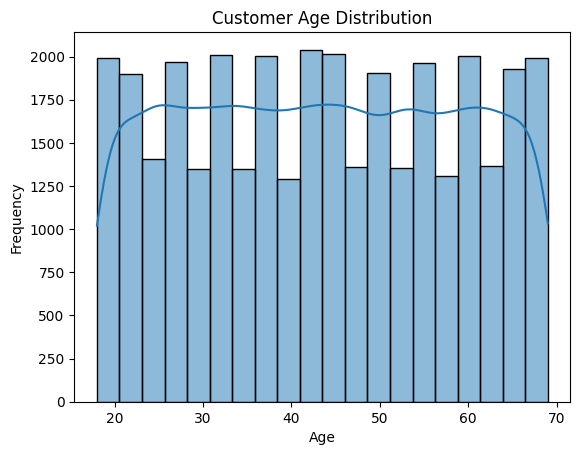

In [40]:
sns.histplot(df['customer_age'], bins=20, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Customer Age Distribution

This visualization shows the distribution of customer ages using a histogram.

The ages are spread fairly evenly across the range from around 18 to 70, indicating a diverse customer base across different age groups.

There is no strong peak or skew, suggesting that customers from all age groups contribute relatively equally.

In [41]:
gender_category=pd.crosstab(df['customer_gender'],df['category'])
gender_category

category,Beauty,Electronics,Fashion,Grocery,Home,Sports,Toys
customer_gender,,,,,,,
Female,2050,3022,2994,1959,2685,2032,2076
Male,1887,2898,3004,1951,2580,1993,1997
Other,166,260,256,148,222,146,174


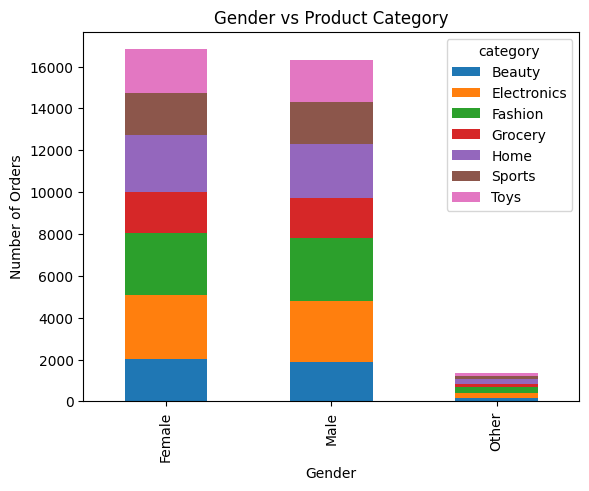

In [42]:
gender_category.plot(kind='bar', stacked=True)
plt.title("Gender vs Product Category")
plt.xlabel("Gender")
plt.ylabel("Number of Orders")
plt.show()

### Gender vs Product Category

This stacked bar chart shows the distribution of product categories across different genders.

Each bar represents a gender group, and the segments within the bar indicate the number of orders for each category.

The distribution appears relatively balanced across categories for both male and female customers, with no single category dominating significantly.

The 'Other' category has comparatively fewer orders across all product types.

This suggests that, in this dataset, customer preferences are fairly evenly distributed across product categories.

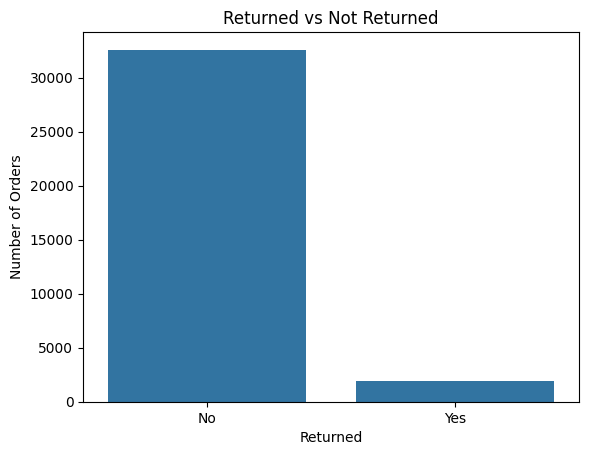

In [43]:
returns = df['returned'].value_counts()

sns.barplot(x=returns.index, y=returns.values)
plt.title("Returned vs Not Returned")
plt.xlabel("Returned")
plt.ylabel("Number of Orders")
plt.show()

### Return Distribution

This visualization shows the number of orders that were returned versus those that were not returned.

It helps in understanding the overall return behavior of customers.

Most orders are not returned, indicating that the majority of transactions are successfully completed without issues.

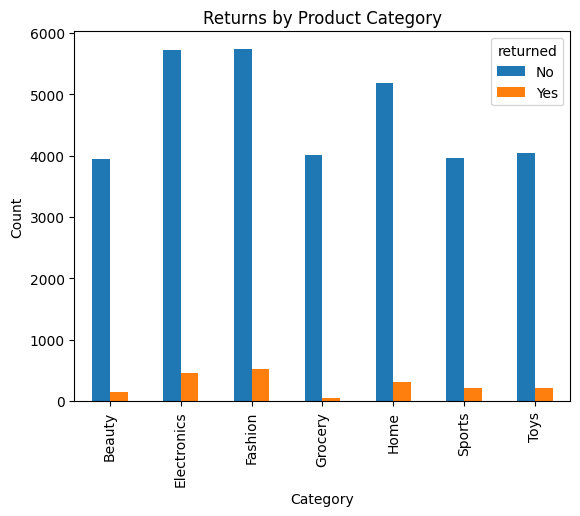

In [44]:
returns_category = pd.crosstab(df['category'], df['returned'])

returns_category.plot(kind='bar')
plt.title("Returns by Product Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

### Returns by Product Category

This visualization shows how product returns vary across different categories.

It helps identify which categories have higher return rates.

Certain categories may have slightly higher returns, which could indicate issues related to product quality, expectations, or delivery.

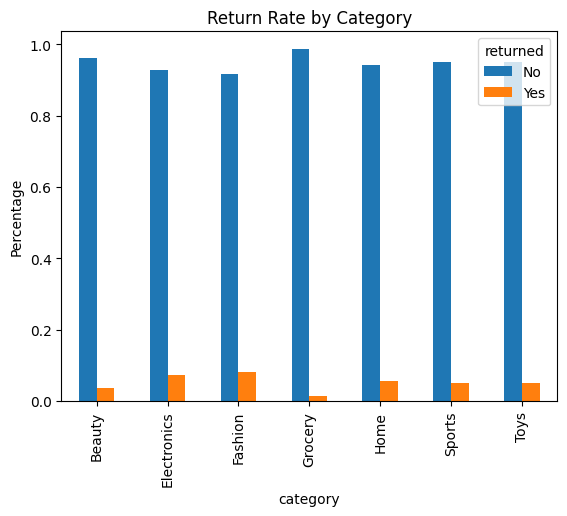

In [45]:
return_rate = df.groupby('category')['returned'].value_counts(normalize=True).unstack()

return_rate.plot(kind='bar')
plt.title("Return Rate by Category")
plt.ylabel("Percentage")
plt.show()

### Return Rate by Category

This visualization represents the proportion of returned and non-returned products within each category.

It provides a clearer understanding of return behavior relative to total orders in each category.

Categories with higher return rates may require further investigation.

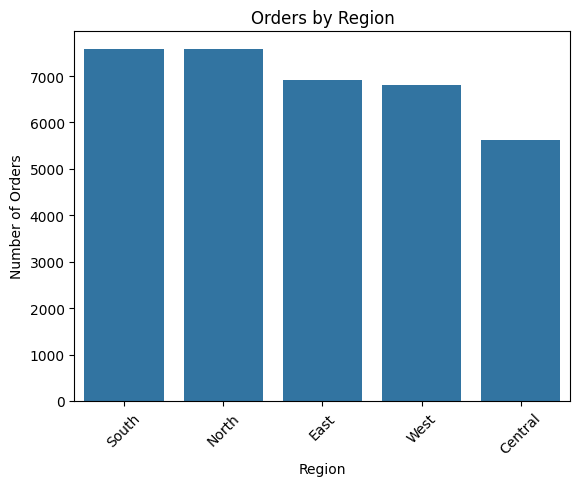

In [46]:
region_counts = df['region'].value_counts()

sns.barplot(x=region_counts.index, y=region_counts.values)
plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### Orders by Region

This visualization shows the number of orders across different regions.

The South and North regions have the highest number of orders, indicating strong customer activity. East and West regions show moderate performance, while Central has the lowest number of orders.

This suggests that demand is higher in certain regions, which may be due to factors like population, accessibility, or customer engagement.

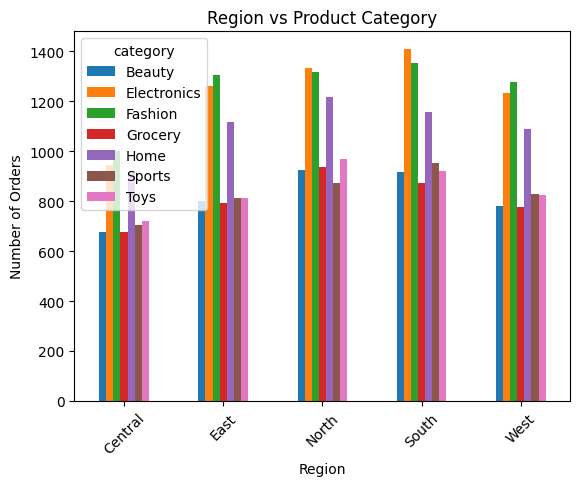

In [50]:
region_category = pd.crosstab(df['region'], df['category'])

region_category.plot(kind='bar')
plt.title("Region vs Product Category")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### Region vs Product Category

This stacked bar chart shows the distribution of product categories across different regions.

Each bar represents a region, and the segments within the bar indicate the number of orders for each product category.

Regions such as North and South appear to have higher total orders, while Central has comparatively lower activity.

The distribution of categories across regions is relatively balanced, with no single category dominating significantly in any region.

This suggests that customer preferences are fairly consistent across different regions in this dataset.

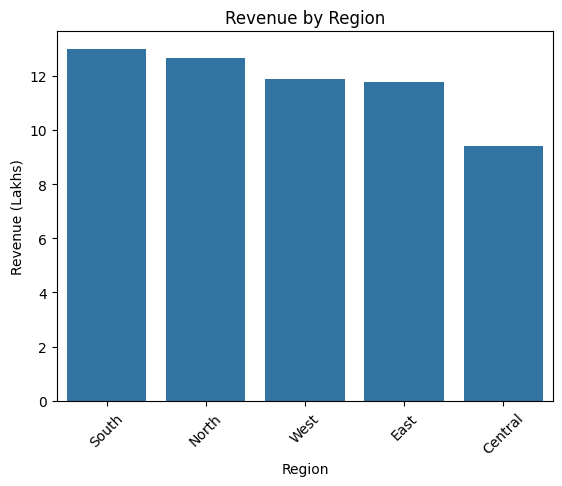

In [52]:
region_revenue = df.groupby('region')['total_amount'].sum().sort_values(ascending=False)
region_revenue = region_revenue / 100000
sns.barplot(x=region_revenue.index, y=region_revenue.values)
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (Lakhs)")
plt.xticks(rotation=45)
plt.show()

### Revenue by Region

This visualization shows the total revenue generated across different regions.

The South region generates the highest revenue, followed closely by the North region. West and East regions show moderate performance, while Central has the lowest revenue contribution.

This indicates that certain regions contribute more significantly to overall business performance, possibly due to higher demand or customer activity in those areas.

## Conclusion

This project analyzed an e-commerce sales dataset to understand customer behavior, product performance, and regional trends.

The analysis showed that product categories are fairly evenly distributed, with no single category dominating significantly. Customer analysis revealed a balanced gender distribution and a wide age range, indicating a diverse customer base.

Most orders were successfully completed with very few returns, suggesting overall customer satisfaction. Payment methods and product preferences were also evenly spread, reflecting consistent behavior across the dataset.

Region-wise analysis showed that certain regions, such as South and North, contribute more to both orders and revenue, while Central has comparatively lower performance.

Overall, the dataset provides a comprehensive view of e-commerce operations, highlighting patterns in sales, customer demographics, and regional performance. While the dataset appears balanced (likely synthetic), it effectively demonstrates how exploratory data analysis can be used to extract meaningful business insights.